In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from joblib import Parallel, delayed

from scipy.special import iv

import pickle

import schwingerModel as sim

In [2]:
m = .2
a = 1
dimx = 16
dimt = 32
beta = 10
totalSteps = 5000

In [ ]:
temp = sim.schwingerModel(metroSteps=totalSteps,beta=beta,dimx=dimx,dimt=dimt,aSpacing=a,fMass=m,cgRtol=1e-5)

In [ ]:
# with open('50kSteps.pkl', 'wb') as f:
#     pickle.dump(temp,f)

In [3]:
with open('50kSteps.pkl', 'rb') as f:
    temp = pickle.load(f)

In [ ]:
rhoBar = sim.analysis.getEffMassRhoBar(temp)
sim.analysis.get_integrated_autocorr_time_statistical(rhoBar,temp.metroSteps)

In [ ]:
bIn = 500
skp = 100

gamma = np.array([[0,1j],[1j,0]])
correlSigma1 = sim.analysis.correlStats(temp, burnIn=bIn,autocorrSkip=skp,Gamma=gamma,includeDisc=False)
effectiveMassSigma1 = sim.analysis.effectiveMassProp(correlSigma1)

gamma = np.array([[1,0],[0,1]])
correlIden = sim.analysis.correlStats(temp, burnIn=bIn,autocorrSkip=skp,Gamma=gamma,includeDisc=False)
effectiveMassIden = sim.analysis.effectiveMassProp(correlIden)

gamma = np.array([[1j,0],[0,-1j]])
correlSigma3 = sim.analysis.correlStats(temp, burnIn=bIn,autocorrSkip=skp,Gamma=gamma,includeDisc=False)
effectiveMassSigma3 = sim.analysis.effectiveMassProp(correlSigma3)

gamma = np.array([[0,1],[-1,0]])
correlSigma2 = sim.analysis.correlStats(temp, burnIn=bIn,autocorrSkip=skp,Gamma=gamma,includeDisc=False)
effectiveMassSigma2 = sim.analysis.effectiveMassProp(correlSigma2)


# correlSmallmu = sim.analysis.correlStats(temp, burnIn=bIn,autocorrSkip=skp,Gamma=gamma,includeDisc=False,chemicalPot=0.3)
# effectiveMass = sim.analysis.effectiveMassStats(temp, burnIn=bIn,autocorrSkip=skp,Gamma=gamma,includeDisc=False,coshExpr=False)
# effectiveMassSmallMu = sim.analysis.effectiveMassStats(temp, burnIn=bIn,autocorrSkip=skp,Gamma=gamma,includeDisc=False,coshExpr=False,chemicalPot=0.3)

100%|██████████| 495/495 [00:45<00:00, 10.93it/s]
/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/analysis.py:162: RuntimeWarning: invalid value encountered in log
  effectiveMass = np.log(np.array(cFunc[:-1])/np.array(cFunc[1:]))
100%|██████████| 495/495 [00:45<00:00, 10.84it/s]


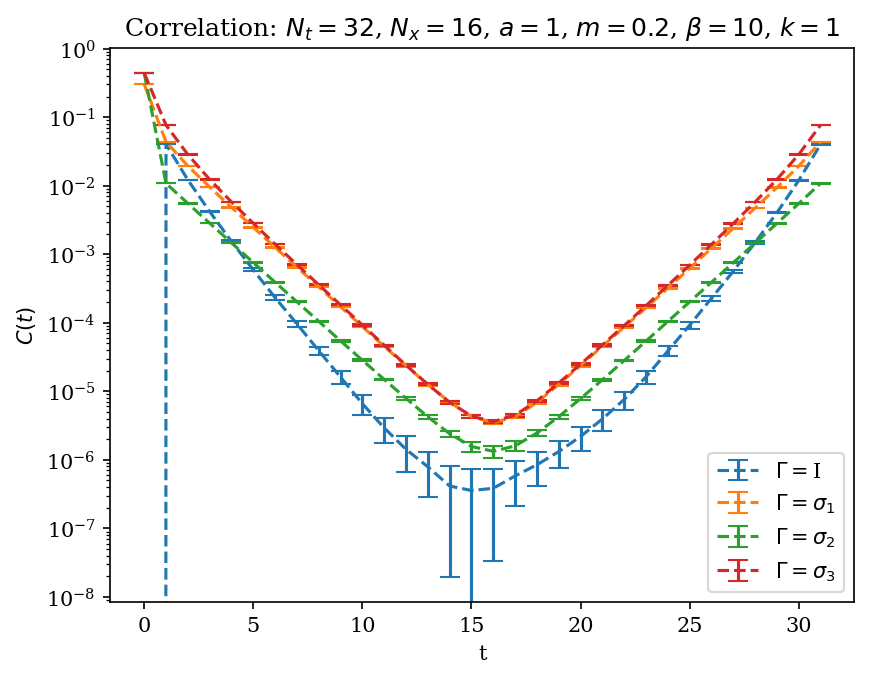

In [15]:
plt.figure(dpi=150)
plt.errorbar(x=np.arange(len(correlIden[0])),y=correlIden[0],yerr=correlIden[1],ls="--",capsize=5,label=r"$\Gamma=$I")

plt.errorbar(x=np.arange(len(correlSigma1[0])),y=correlSigma1[0],yerr=correlSigma1[1],ls="--",capsize=5,label=r"$\Gamma=\sigma_1$")
plt.errorbar(x=np.arange(len(correlSigma2[0])),y=np.abs(correlSigma2[0]),yerr=correlSigma2[1],ls="--",capsize=5,label=r"$\Gamma=\sigma_2$")
plt.errorbar(x=np.arange(len(correlSigma3[0])),y=correlSigma3[0],yerr=correlSigma3[1],ls="--",capsize=5,label=r"$\Gamma=\sigma_3$")

plt.semilogy()
plt.xlabel("t")
plt.ylabel(r"$C(t)$")
plt.title(rf"Correlation: $N_t = {dimt}$, $N_x={dimx}$, $a={a}$, $m={m}$, $\beta={beta}$, $k=1$")
plt.legend()

(0.0, 2.0)

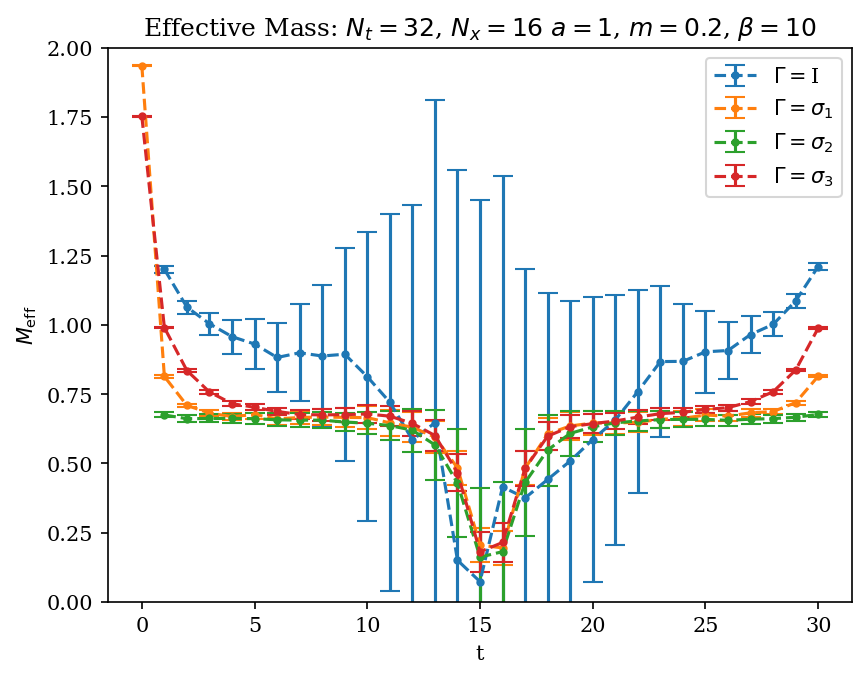

In [16]:
plt.figure(dpi=150)
plt.errorbar(x=np.arange(len(effectiveMassIden[0])),y=np.abs(effectiveMassIden[0]),yerr=effectiveMassIden[1],ls="--",marker=".",capsize=5,label=r"$\Gamma=$I")
plt.errorbar(x=np.arange(len(effectiveMassSigma1[0])),y=np.abs(effectiveMassSigma1[0]),yerr=effectiveMassSigma1[1],ls="--",marker=".",capsize=5,label=r"$\Gamma=\sigma_1$")
plt.errorbar(x=np.arange(len(effectiveMassSigma2[0])),y=np.abs(effectiveMassSigma2[0]),yerr=effectiveMassSigma2[1],ls="--",marker=".",capsize=5,label=r"$\Gamma=\sigma_2$")
plt.errorbar(x=np.arange(len(effectiveMassSigma3[0])),y=np.abs(effectiveMassSigma3[0]),yerr=effectiveMassSigma3[1],ls="--",marker=".",capsize=5,label=r"$\Gamma=\sigma_3$")
plt.xlabel("t")
plt.ylabel(r"$M_{\text{eff}}$")
plt.title(rf"Effective Mass: $N_t = {dimt}$, $N_x={dimx}$ $a={a}$, $m={m}$, $\beta={beta}$")
plt.legend()
plt.ylim([0,2])

In [ ]:
bIn = 500
skp = 100

densities = []
mus = np.linspace(0,1.5,31)
for mu in mus:
    print(mu, end=": \n")
    densities.append(sim.analysis.numDensityStats(temp,burnIn=bIn,autocorrSkip=skp, chemicalPot=mu))

0.0: 


100%|██████████| 495/495 [01:00<00:00,  8.24it/s]


0.05: 


100%|██████████| 495/495 [00:56<00:00,  8.70it/s]


0.1: 


100%|██████████| 495/495 [00:57<00:00,  8.66it/s]


0.15000000000000002: 


100%|██████████| 495/495 [00:56<00:00,  8.79it/s]


0.2: 


 88%|████████▊ | 435/495 [00:52<00:07,  7.60it/s]

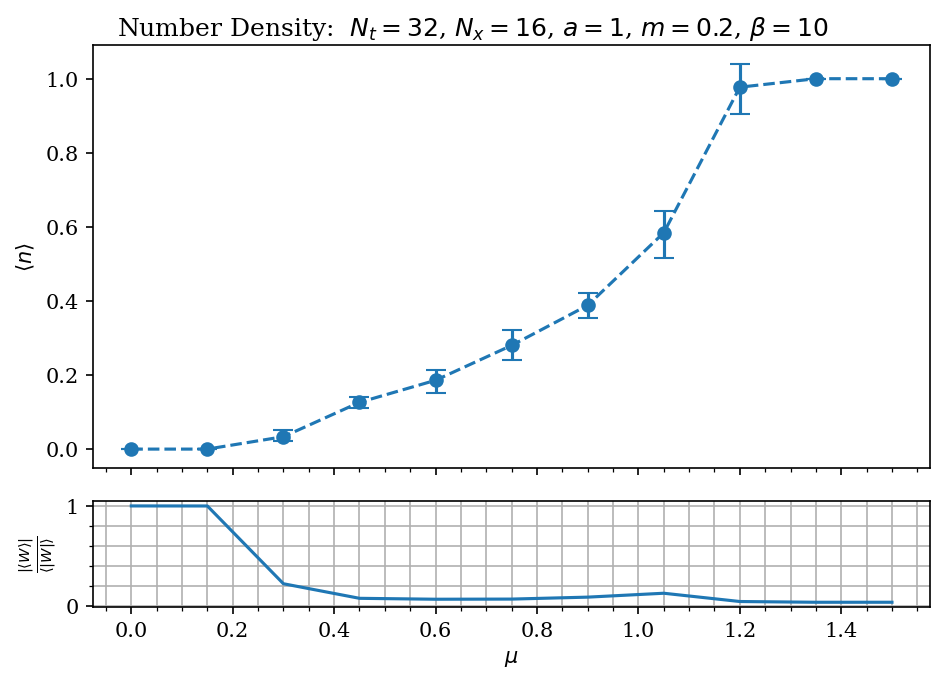

In [23]:
dens = np.array([densities[i][0] for i in range(len(densities))])
densErr = np.array([densities[i][1] for i in range(len(densities))]).T
validity = np.array([densities[i][2] for i in range(len(densities))])

fig, ax = plt.subplots(dpi=150, nrows=2, height_ratios=[4,1],sharex=True)

ax[0].errorbar(x=mus,y=dens,yerr=np.abs(densErr),capsize=5, marker="o",ls="--")
ax[0].set_ylabel(r"$\langle n\rangle$")
ax[1].set_xlabel(r"$\mu$")

ax[1].plot(mus,validity)
ax[1].set_ylabel(r"$\frac{|\langle W\rangle|}{\langle |W| \rangle}$")
ax[1].minorticks_on()
ax[1].grid(which="both")

fig.suptitle(rf"Number Density:  $N_t = {dimt}$, $N_x={dimx}$, $a={a}$, $m={m}$, $\beta={beta}$",y=.94)
plt.tight_layout()

In [14]:
gamma = np.array([[0,-1j],[1j,0]])
bIn = 500
skp = 500

correlks = []
effMassks = []
ks = np.arange(0,4)
for mom in ks:
    correlSigma3 = sim.analysis.correlStats(temp, burnIn=bIn,autocorrSkip=skp,Gamma=gamma,includeDisc=False,k=mom)
    effectiveMassSigma3 = sim.analysis.effectiveMassProp(correlSigma3)
    
    correlks.append(correlSigma3)
    effMassks.append(effectiveMassSigma3)

100%|██████████| 99/99 [00:05<00:00, 19.73it/s]
/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/analysis.py:162: RuntimeWarning: invalid value encountered in log
  effectiveMass = np.log(np.array(cFunc[:-1])/np.array(cFunc[1:]))
100%|██████████| 99/99 [00:09<00:00, 10.11it/s]


Text(0.5, 1.0, 'Correlation: $N_t = 32$, $N_x=16$, $a=1$, $m=0.2$, $\\beta=10$, $\\Gamma=\\sigma_2$')

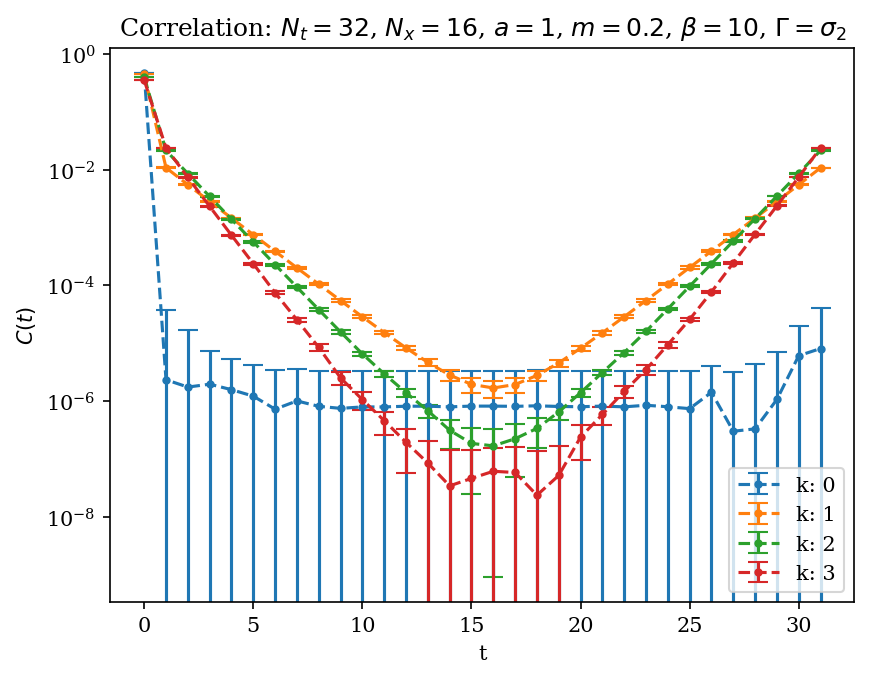

In [15]:
plt.figure(dpi=150)
for i in range(len(ks)):
    plt.errorbar(x=np.arange(len(correlks[i][0])),y=np.abs(correlks[i][0]),yerr=correlks[i][1],ls="--",marker=".",capsize=5,label=f"k: {ks[i]}")

plt.semilogy()
plt.legend()

plt.xlabel("t")
plt.ylabel(r"$C(t)$")
plt.title(rf"Correlation: $N_t = {dimt}$, $N_x={dimx}$, $a={a}$, $m={m}$, $\beta={beta}$, $\Gamma=\sigma_2$")


Text(0.5, 1.0, 'Effective Mass: $N_t = 32$, $N_x=16$, $a=1$, $m=0.2$, $\\beta=10$, $\\Gamma=\\sigma_2$')

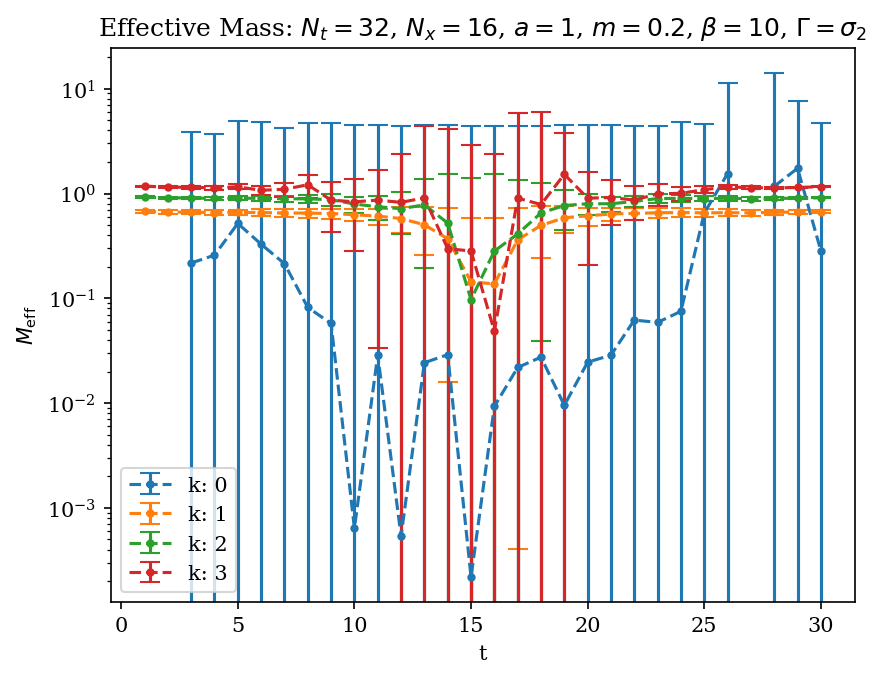

In [18]:
plt.figure(dpi=150)
for i in range(len(ks)):
    plt.errorbar(x=np.arange(len(effMassks[i][0])),y=np.abs(effMassks[i][0]),yerr=effMassks[i][1],ls="--",marker=".",capsize=5,label=f"k: {ks[i]}")

plt.semilogy()
plt.legend()

plt.xlabel("t")
plt.ylabel(r"$M_{\text{eff}}$")
plt.title(rf"Effective Mass: $N_t = {dimt}$, $N_x={dimx}$, $a={a}$, $m={m}$, $\beta={beta}$, $\Gamma=\sigma_2$")


Text(0.5, 1.0, 'Dispersion Relation: $N_t = 32$, $N_x=16$, $a=1$, $m=0.2$, $\\beta=10$, $\\Gamma=\\sigma_3$')

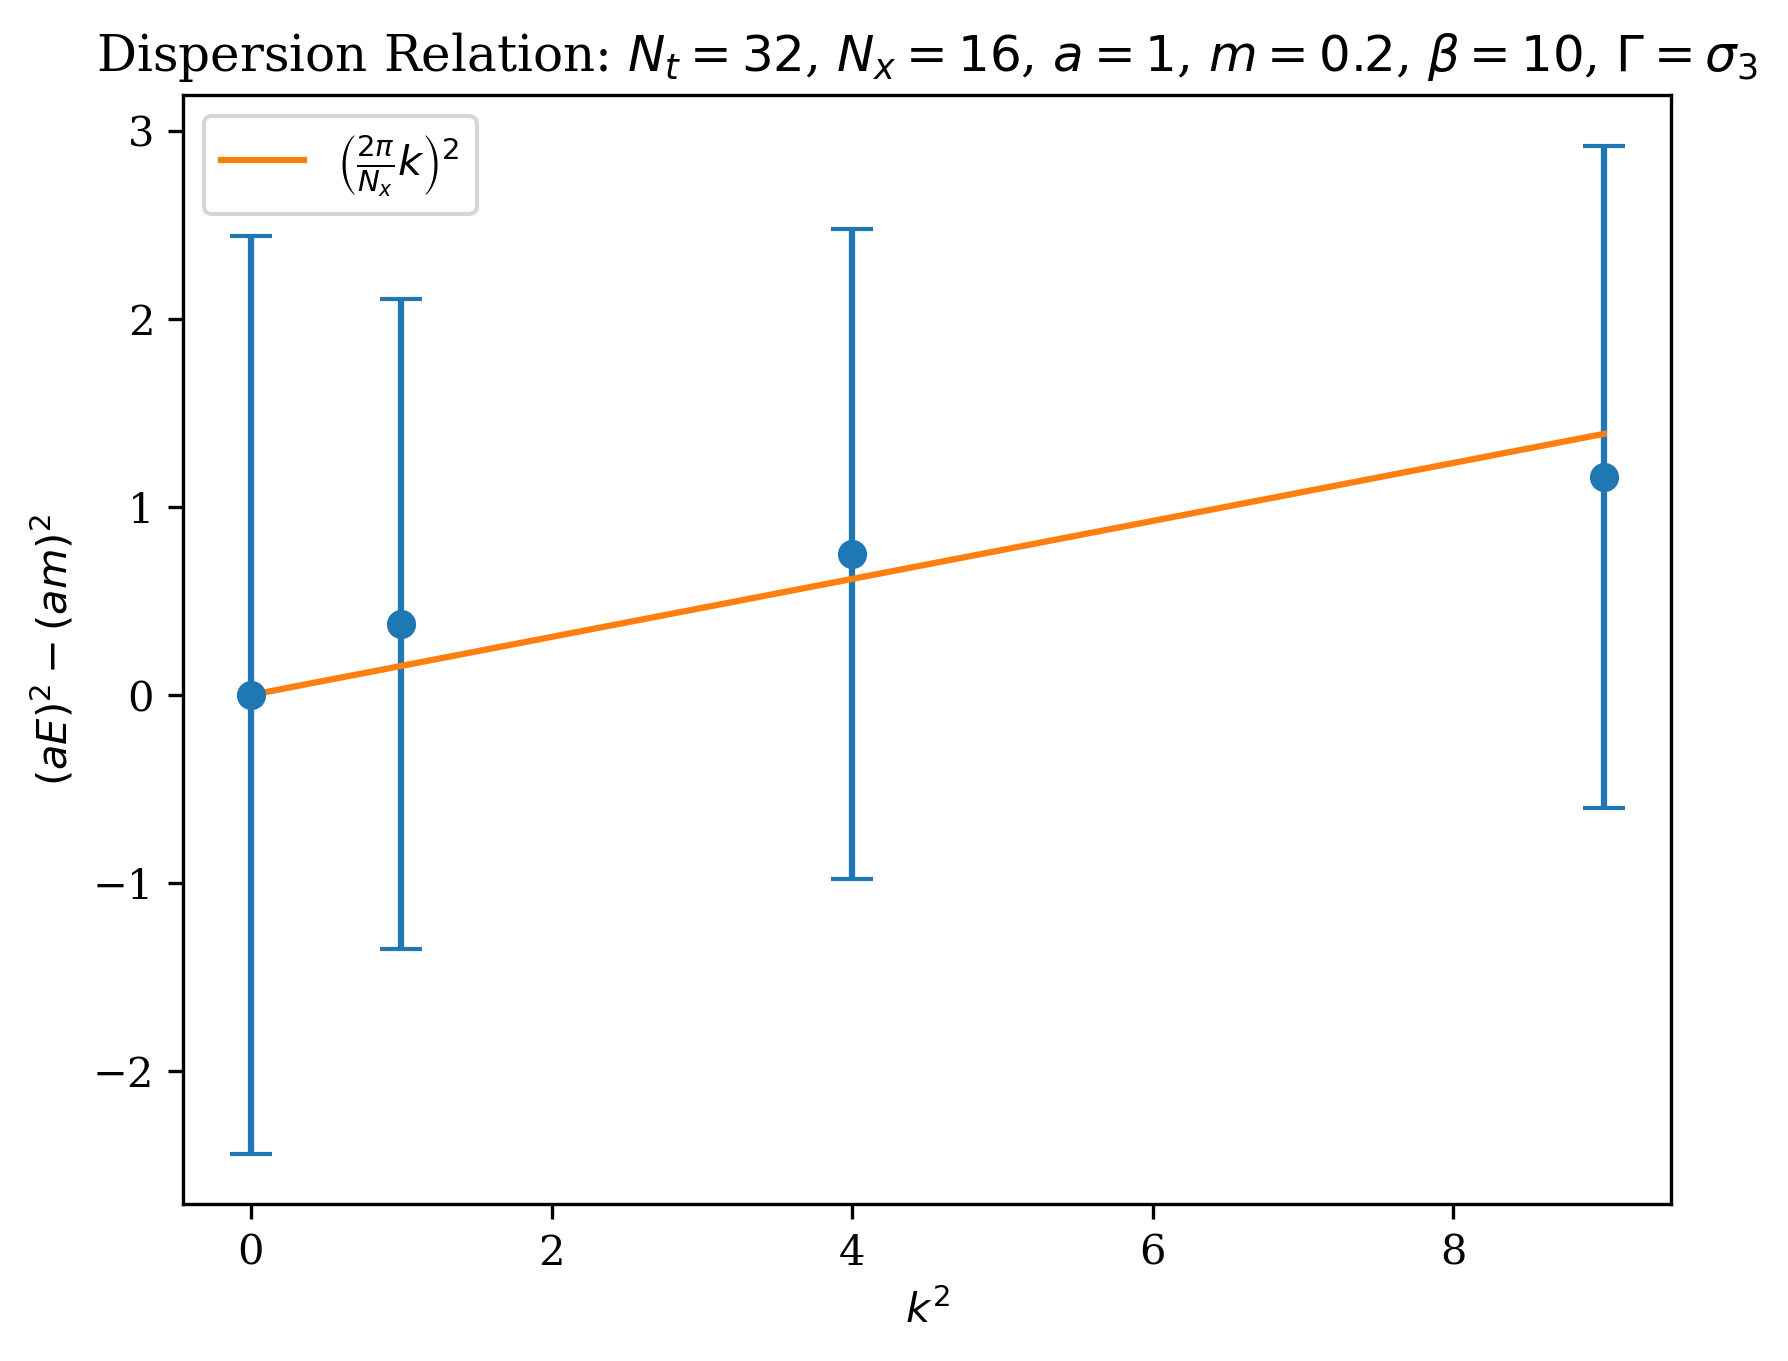

In [21]:
t=7
energyEstimates = np.array([effMassks[i][0][t] for i in ks])
energyEstimatesErr = np.array([effMassks[i][1][t] for i in ks])

#E^2=p^2+m^2
ps = (2*np.pi/dimx)*ks

kineticDispersion = energyEstimates**2-energyEstimates[0]**2

dispErr = 2*np.sqrt((energyEstimates*energyEstimatesErr)**2+(energyEstimates[0]*energyEstimatesErr[0])**2)

plt.figure(dpi=300)
plt.errorbar(x=ks**2, y=kineticDispersion, yerr=dispErr, capsize=5, ls="", marker="o")
plt.plot(ks**2,ps**2, label=r"$\left(\frac{2 \pi}{N_x}k\right)^2$" )
plt.xlabel("$k^2$")
plt.ylabel("$(aE)^2-(am)^2$")
plt.legend()
plt.title(rf"Dispersion Relation: $N_t = {dimt}$, $N_x={dimx}$, $a={a}$, $m={m}$, $\beta={beta}$, $\Gamma=\sigma_3$")